## Modeling
In this notebook I test out different models and how they work on the dataset.

In [1]:
import pandas as pd
import numpy as np

# Import models from script folder
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath('..'))

from script import data_preprocessing as dp
from script import data_visualization as dv
from script import data_modeling as dm
from script import anomaly_detection as ad
from script import oversampling as ov

In [2]:
# load in the data
names = ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']
data = dp.load_split_data(names, 'dataset1')
X_train, X_val, X_test, y_train, y_val, y_test = data['X_train'], data['X_val'], data['X_test'], data['y_train'], data['y_val'], data['y_test']

Load data with base name: dataset1


In [3]:
X_train.head()

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Flow rate (Mean)_rolling_mean_10,Flow rate (Mean)_rolling_min_10,Flow rate (Mean)_rolling_max_10,TS outlet pressure (Mean)_rolling_mean_10,...,Tank temperature (Mean)_rolling_mean_10,Tank temperature (Mean)_rolling_min_10,Temperature TS inlet (Mean)_rolling_mean_10,Temperature TS inlet (Mean)_rolling_min_10,Temperature TS inlet (Mean)_rolling_max_10,Bypass temperature (Mean)_rolling_mean_10,Bypass temperature (Mean)_rolling_min_10,Bypass temperature (Mean)_rolling_max_10,Anomaly_rolling_mean_10,Anomaly_rolling_min_10
Elapsed_seconds,,,,,,,,,,,,,,,,,,,,,
0.00,3.769735,3.891036,3.855507,3.851978,-5.461369,0.705783,3.769339,3.772633,3.766054,3.891402,...,-8.801432,-8.551901,-6.131227,-6.132574,-6.102468,0.706074,0.746822,0.665663,-0.109654,-0.109217
0.05,3.769277,3.913425,3.872355,3.880656,-5.523070,0.671932,3.769110,3.772175,3.766054,3.902598,...,-8.837420,-8.624067,-6.144313,-6.159397,-6.102468,0.689142,0.712944,0.665663,-0.109654,-0.109217
0.10,3.769735,3.918827,3.902206,3.917088,-5.476060,0.711426,3.769186,3.772175,3.766054,3.908131,...,-8.821062,-8.624067,-6.146183,-6.159397,-6.102468,0.696668,0.712944,0.671305,-0.109654,-0.109217
0.15,3.766759,3.889493,3.872355,3.874455,-5.487812,0.694498,3.768481,3.769658,3.766054,3.903563,...,-8.832513,-8.624067,-6.148052,-6.159397,-6.102468,0.696198,0.712944,0.671305,-0.109654,-0.109217
0.20,3.766302,3.894123,3.890171,3.886086,-5.478998,0.705783,3.767966,3.769201,3.766054,3.901748,...,-8.842001,-8.630627,-6.148426,-6.159397,-6.102468,0.698173,0.712944,0.671305,-0.109654,-0.109217


In [4]:
y_train.head()

,Plug_future
Elapsed_seconds,
0.00,0.0
0.05,0.0
0.10,0.0
0.15,0.0
0.20,0.0


### Baseline model

In [5]:
baseline = dm.baseline_model(X_train, y_train, X_val, y_val)

Validation F1 Score: 0.673
Validation set results (baseline):
              precision    recall  f1-score   support

         0.0      0.772     1.000     0.872      1221
         1.0      0.000     0.000     0.000       360

    accuracy                          0.772      1581
   macro avg      0.386     0.500     0.436      1581
weighted avg      0.596     0.772     0.673      1581



/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
dp.print_distribution(y_train, "Training set")

Training set distribution:
  Class 0.0: 278514 samples
  Class 1.0: 51233 samples


### Upsample values

In [7]:
X_train, y_train = ov.oversample_minority(
    X_train,
    y_train,
    target_ratio=1.0,       
    random_state=42
)

🪜 Oversampling minority class to balance dataset...
 - Original minority samples: 51233, majority samples: 278514
 - After oversampling: minority samples: 278514, majority samples: 278514
⚖️ Oversampling completed.


In [8]:
# Check class balance for the target variable
dp.print_distribution(y_train, "Training set")

Training set distribution:
  Class 0.0: 278514 samples
  Class 1.0: 278514 samples


### Combing train and val for visualization
Combining the two sets for visualization purposes later

In [9]:
X_train_val = pd.concat([X_train, X_val]).reset_index(drop=True)
y_train_val = pd.concat([y_train, y_val]).reset_index(drop=True)

X_train_val_unscaled = dp.descale_features(X_train_val)
X_train_val_unscaled = X_train_val_unscaled.reset_index(drop=True)
y_train_val = y_train_val.reset_index(drop=True)

X_train_val_unscaled["Plug"] = y_train_val
X_train_val_unscaled


⚙️ Features descaled using StandardScaler inverse transform


,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Bypass temperature (Mean),Flow rate (Mean)_rolling_mean_10,Flow rate (Mean)_rolling_min_10,Flow rate (Mean)_rolling_max_10,TS outlet pressure (Mean)_rolling_mean_10,...,Tank temperature (Mean)_rolling_min_10,Temperature TS inlet (Mean)_rolling_mean_10,Temperature TS inlet (Mean)_rolling_min_10,Temperature TS inlet (Mean)_rolling_max_10,Bypass temperature (Mean)_rolling_mean_10,Bypass temperature (Mean)_rolling_min_10,Bypass temperature (Mean)_rolling_max_10,Anomaly_rolling_mean_10,Anomaly_rolling_min_10,Plug
0,2006.990755,0.663001,1.006496,1.122522,-6.231957,25.589479,2006.990755,2006.990755,2006.990755,0.663001,...,-6.344172,-6.309016,-6.309016,-6.309016,25.589479,25.589479,25.589479,0.0,1.734723e-18,0.0
1,2006.802163,0.666047,1.010171,1.129320,-6.287087,25.573727,2006.896459,2006.802163,2006.990755,0.664524,...,-6.373047,-6.318204,-6.327391,-6.309016,25.581603,25.573727,25.589479,0.0,1.734723e-18,0.0
2,2006.990755,0.666782,1.016682,1.137956,-6.245083,25.592105,2006.927891,2006.802163,2006.990755,0.665277,...,-6.373047,-6.319516,-6.327391,-6.309016,25.585104,25.573727,25.592105,0.0,1.734723e-18,0.0
3,2005.764905,0.662791,1.010171,1.127850,-6.255584,25.584228,2006.637145,2005.764905,2006.990755,0.664655,...,-6.373047,-6.320829,-6.327391,-6.309016,25.584885,25.573727,25.592105,0.0,1.734723e-18,0.0
4,2005.576313,0.663421,1.014057,1.130607,-6.247708,25.589479,2006.424978,2005.576313,2006.990755,0.664408,...,-6.375672,-6.321091,-6.327391,-6.309016,25.585804,25.573727,25.592105,0.0,1.734723e-18,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558604,75.239493,0.064039,0.065097,0.089872,0.491254,26.437505,77.398875,75.239493,79.011340,0.065016,...,-2.629825,-0.089925,-0.205691,-0.024560,26.477938,26.437505,26.511018,0.0,1.734723e-18,1.0
558605,74.862309,0.061939,0.065097,0.103285,0.383619,26.487389,77.021691,74.862309,79.011340,0.064974,...,-2.590450,-0.091237,-0.218816,-0.024560,26.475575,26.437505,26.495266,0.0,1.734723e-18,1.0
558606,74.296532,0.065404,0.066567,0.089872,0.331115,26.474262,76.578499,74.296532,79.011340,0.066265,...,-2.645575,-0.098850,-0.242442,-0.024560,26.473737,26.437505,26.495266,0.0,1.734723e-18,1.0
558607,74.862309,0.055324,0.055961,0.092812,0.333740,26.440131,76.220173,74.296532,79.011340,0.064344,...,-2.708574,-0.118538,-0.263443,-0.024560,26.469273,26.437505,26.495266,0.0,1.734723e-18,1.0


# Semi unsupervised

### Anomaly detection
Testing to see how anomaly detection models do on this dataset.

In [10]:
models = ad.train_anomaly_models(X_train, y_train)

Isolation Forest trained with contamination=0.01


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-298.173382244457173 > -444.054882165157039). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-295.919038254903455 > -413.574150816538179). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-297.999813860077211 > -415.568777674744695). You may want to try with a higher value of support_fraction (cu

Elliptic Envelope trained with contamination=0.01, support_fraction=None
Trained 2 anomaly detection models.


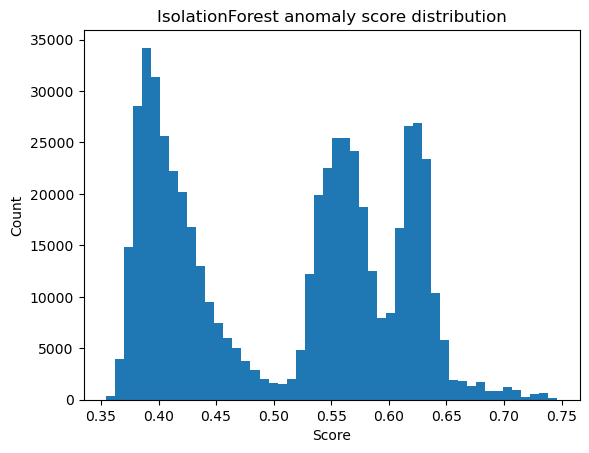

In [11]:
dv.plot_anomaly_score_distribution(models["IsolationForest"], X_train)

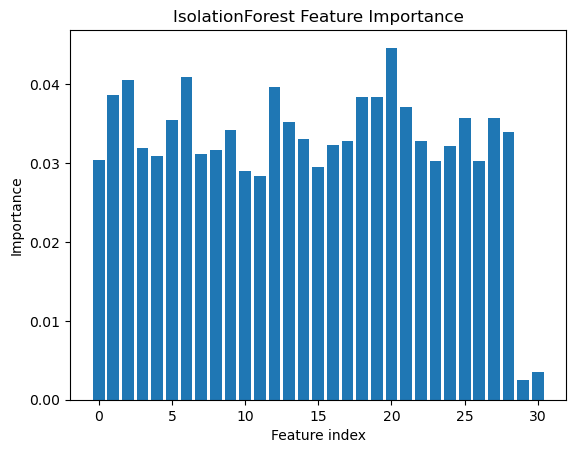

In [12]:
dv.feature_importnace_anomaly(models["IsolationForest"])

In [13]:
ad.get_anomaly_scores(models, X_val)

{'IsolationForest': array([-0.03339171, -0.03339171, -0.03339171, ...,  0.07104804,
         0.07061941,  0.07061941]),
 'EllipticEnvelope': array([1367706.15983356, 1366700.48080265, 1365663.41229744, ...,
        1570402.04257737, 1570390.49023431, 1570640.37127498])}

In [14]:
results = ad.predict_anomalies(models, X_val)
results

Predicting anomalies with IsolationForest...
Anomalies predicted with IsolationForest.
Anomaly counts:
(array([0, 1]), array([707, 874]))
Predicting anomalies with EllipticEnvelope...
Anomalies predicted with EllipticEnvelope.
Anomaly counts:
(array([0]), array([1581]))
Anomaly prediction completed for all models.


{'IsolationForest': array([1, 1, 1, ..., 0, 0, 0]),
 'EllipticEnvelope': array([0, 0, 0, ..., 0, 0, 0])}

In [15]:
predictions = results["IsolationForest"]

translated = np.where(predictions == 1, 0, 1)

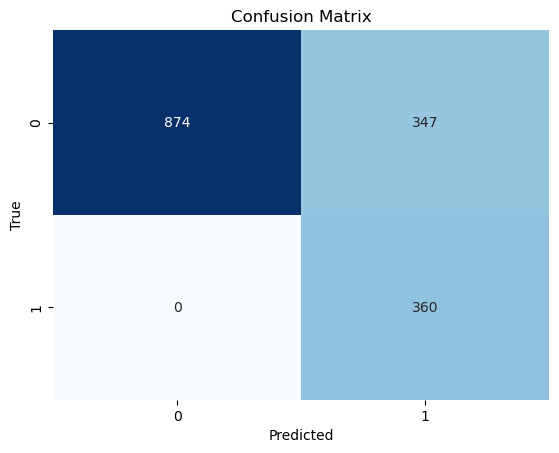

In [16]:
dv.plot_confusion_matrix(y_val, translated)

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_val, translated)
recall = recall_score(y_val, translated)
f1 = f1_score(y_val, translated)

precision, recall, f1


(0.5091937765205092, 1.0, 0.6747891283973758)

In [18]:
# show anomaly counts for each model
for model_name, preds in results.items():
    unique, counts = np.unique(preds, return_counts=True)
    print(f"Anomaly counts for {model_name}: {dict(zip(unique, counts))}")

Anomaly counts for IsolationForest: {np.int64(0): np.int64(707), np.int64(1): np.int64(874)}
Anomaly counts for EllipticEnvelope: {np.int64(0): np.int64(1581)}


In [19]:
# check feature names 
X_train_val.columns
X_train.columns

print("diff", set(X_train_val.columns) - set(X_train.columns))

diff set()


In [20]:
import numpy as np 
from sklearn.metrics import f1_score


results = ad.predict_anomalies({"IsolationForest": models['IsolationForest']}, X_train_val)
translated = np.where(results['IsolationForest'] == 1, 0, 1)

f1 = f1_score(y_val, translated)
print("f1 Score on Validation Set for Isolation forest:", f1)
dv.visualize_predicted_vs_true(X_train_val_unscaled, translated)

Predicting anomalies with IsolationForest...
Anomalies predicted with IsolationForest.
Anomaly counts:
(array([0, 1]), array([554553,   4056]))
Anomaly prediction completed for all models.


ValueError: Found input variables with inconsistent numbers of samples: [1581, 558609]

In [ ]:
isolation_forest_param_grid = {
        'n_estimators': [50, 100, 200, 300],
        'max_samples': [0.5, 0.7, 1.0],
        'max_features': [0.5, 0.7, 1.0],
        'contamination': [0.01, 0.05, 0.1]
    }

best_isolation_forest_model, best_isolation_forest_params, best_isolation_forest_score = ad.hyperparameter_search(models["IsolationForest"], isolation_forest_param_grid, X_train_val)

Starting hyperparameter search for IsolationForest...


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 947, in _score
    scores = scorer(estimator, X_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: _BaseScorer.__call__() missing 1 required positional argument: 'y_true'

  warnings.warn(
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 947, in _score
    scores = scorer(estimator, 

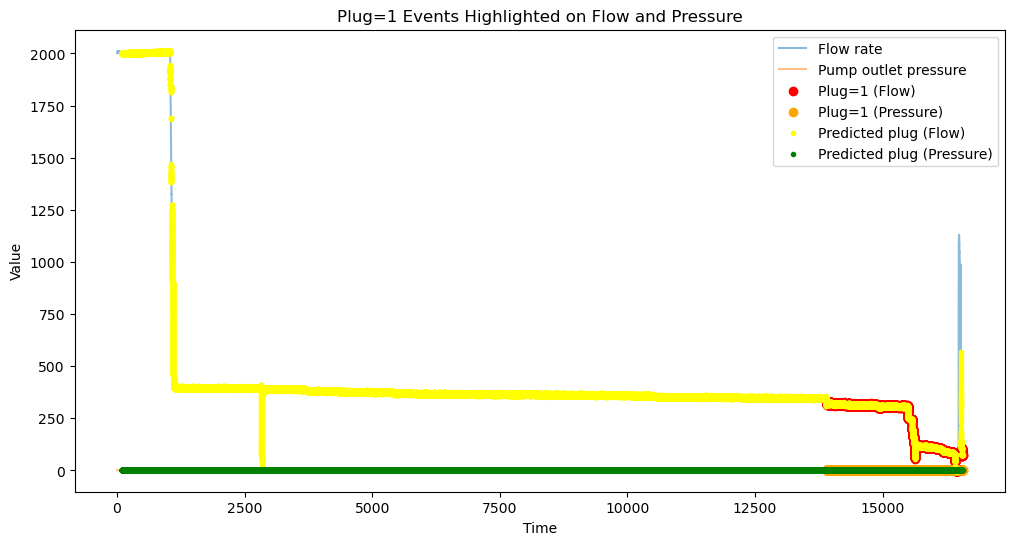

In [ ]:
best_isolation_forest_model, best_isolation_forest_params, best_isolation_forest_score
dv.visualize_predicted_vs_true(X_train_val_unscaled, translated)

Predicting anomalies with EllipticEnvelope...
Anomalies predicted with EllipticEnvelope.
Anomaly counts:
(array([0, 1]), array([328028,   3300]))
Anomaly prediction completed for all models.
f1 Score on Training + Validation Set for EllipticEnvelope: 0.2718132031684232


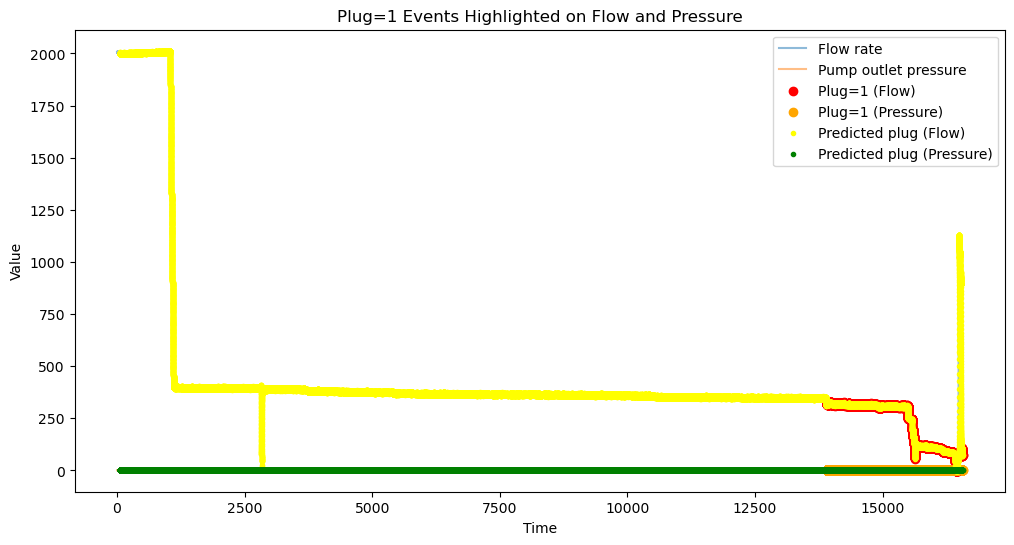

In [ ]:
import numpy as np 
from sklearn.metrics import f1_score


results = ad.predict_anomalies({"EllipticEnvelope": models['EllipticEnvelope']}, X_train_val)
translated = np.where(results['EllipticEnvelope'] == 1, 0, 1)

f1 = f1_score(y_train_val, translated)
print("f1 Score on Training + Validation Set for EllipticEnvelope:", f1)

dv.visualize_predicted_vs_true(X_train_val_unscaled, translated)

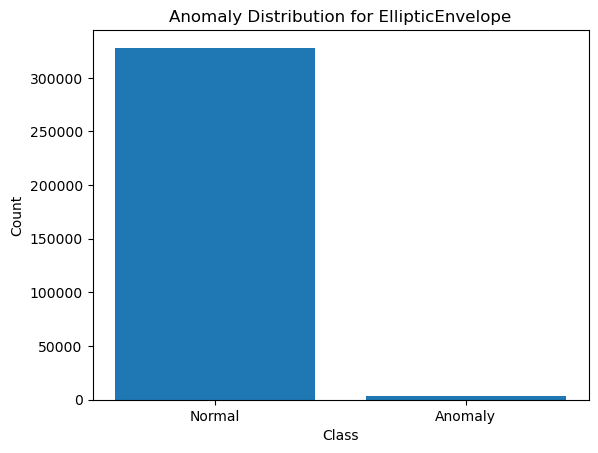

In [ ]:
# Show distribution of predicted anomalies for each model
for model_name, preds in results.items():
    dv.plot_anomaly_distribution(preds, model_name)



# Supervised

## Finding the best model
Training and evaluating different models to find the best one.
Performing hyperparametersearch on the models to find the best hyperparameters as well.

In [ ]:
y_train.value_counts(normalize=True)

Plug_future
0.0            0.844629
1.0            0.155371
Name: proportion, dtype: float64

In [ ]:
best_model = dm.find_best_model(X_train, y_train, X_val, y_val, verbose_level=2, visualize=False)


🔍 Tuning Random Forest...
Searching over 4 hyperparameter combinations...


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Params: {'n_estimators': 100, 'max_depth': 10} | Validation F1 Score = 0.7164


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Params: {'n_estimators': 100, 'max_depth': 20} | Validation F1 Score = 0.7186


...

Params: {'hidden_layer_sizes': (100, 50), 'activation': 'tanh', 'solver': 'sgd'} | Validation F1 Score = 0.5676

✅ Best parameters found: {'hidden_layer_sizes': (100, 50), 'activation': 'relu', 'solver': 'adam'}
Best validation F1 Score: 0.7325
Best ANN model with params: {'hidden_layer_sizes': (100, 50), 'activation': 'relu', 'solver': 'adam'} achieved validation F1 Score: 0.7325

🔍 Tuning CNN...
Searching over 2 hyperparameter combinations...


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Params: {'hidden_layer_sizes': (100, 50), 'activation': 'relu', 'solver': 'adam'} | Validation F1 Score = 0.7347


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Params: {'hidden_layer_sizes': (150, 75), 'activation': 'relu', 'solver': 'adam'} | Validation F1 Score = 0.7332

✅ Best parameters found: {'hidden_layer_sizes': (100, 50), 'activation': 'relu', 'solver': 'adam'}
Best validation F1 Score: 0.7347
Best CNN model with params: {'hidden_layer_sizes': (100, 50), 'activation': 'relu', 'solver': 'adam'} achieved validation F1 Score: 0.7347

Summary of Best Validation F1 Scores:
Random Forest: 0.7186
Logistic Regression: 0.6963
SVM: 0.7080
XGBoost: 0.7108
KNN: 0.6477
Naive Bayes: 0.0488
ANN: 0.7325
CNN: 0.7347

🏆 Best overall model: CNN with validation F1 Score: 0.7347


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptro

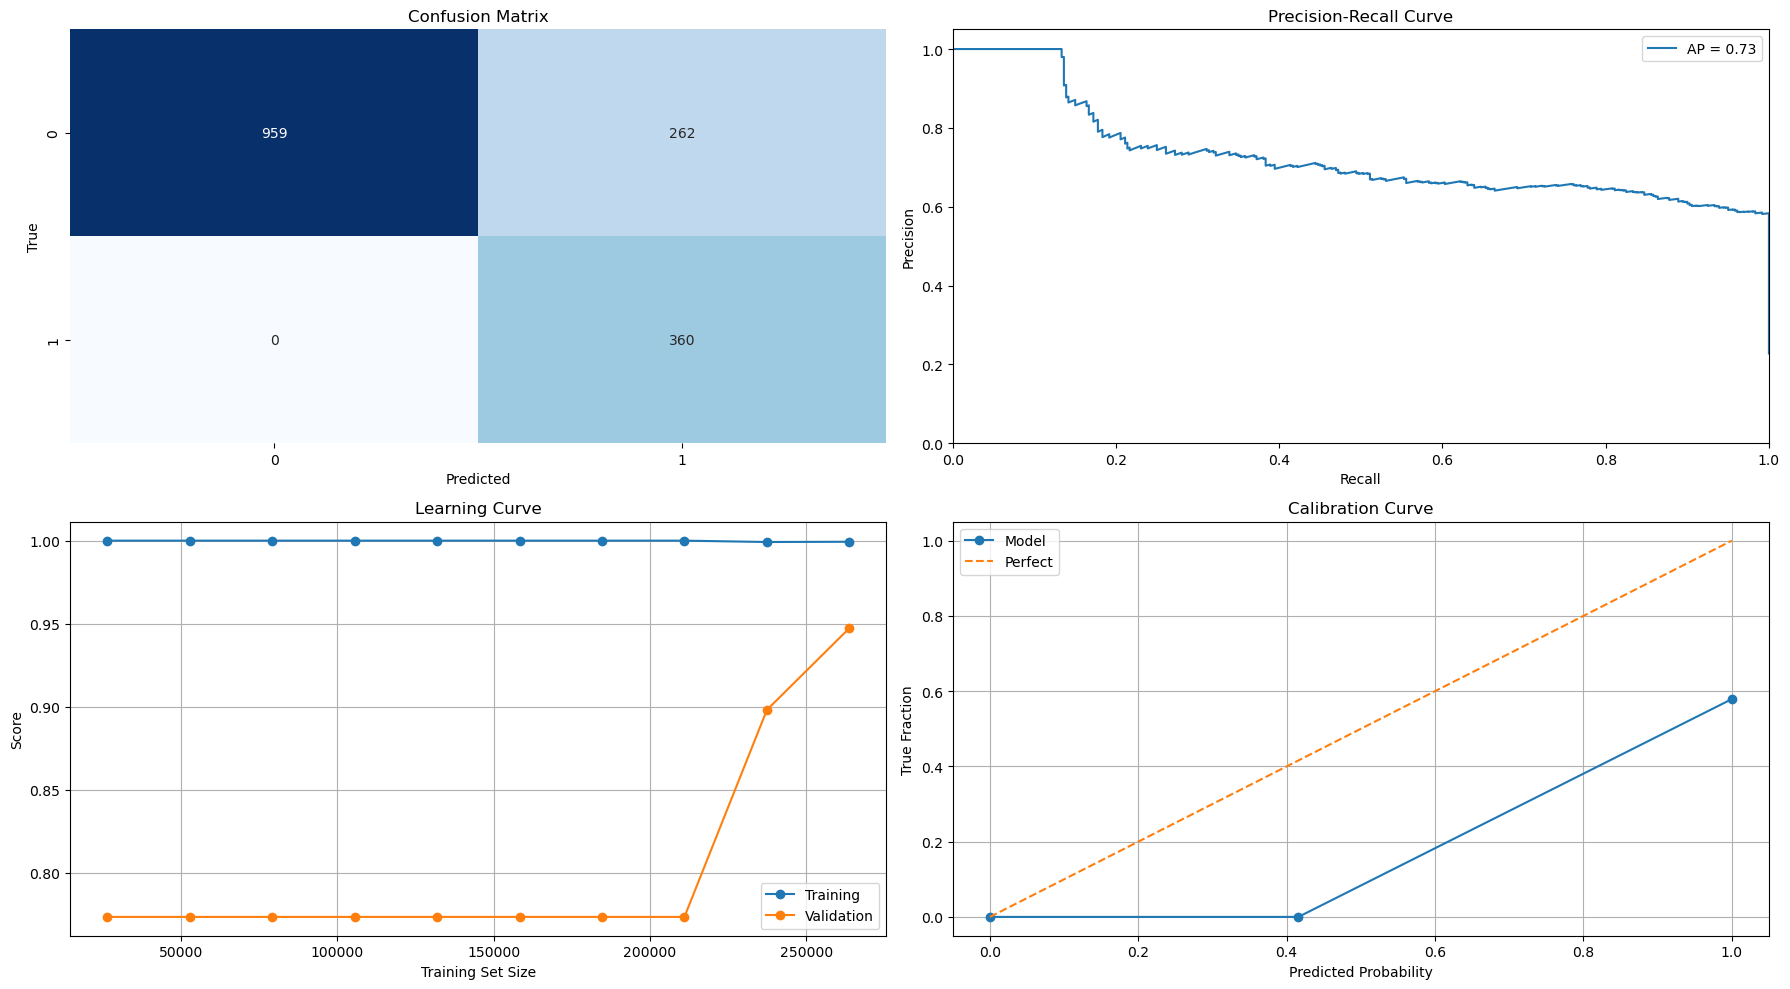

In [ ]:
train_sizes, train_scores, val_scores = dm.get_learning_curve_data(best_model, X_train, y_train)
y_pred_proba = dv.get_y_scores(best_model, X_val)

dv.plot_all(best_model, X_val, y_val, train_sizes, train_scores, val_scores)

⚙️ Features descaled using StandardScaler inverse transform


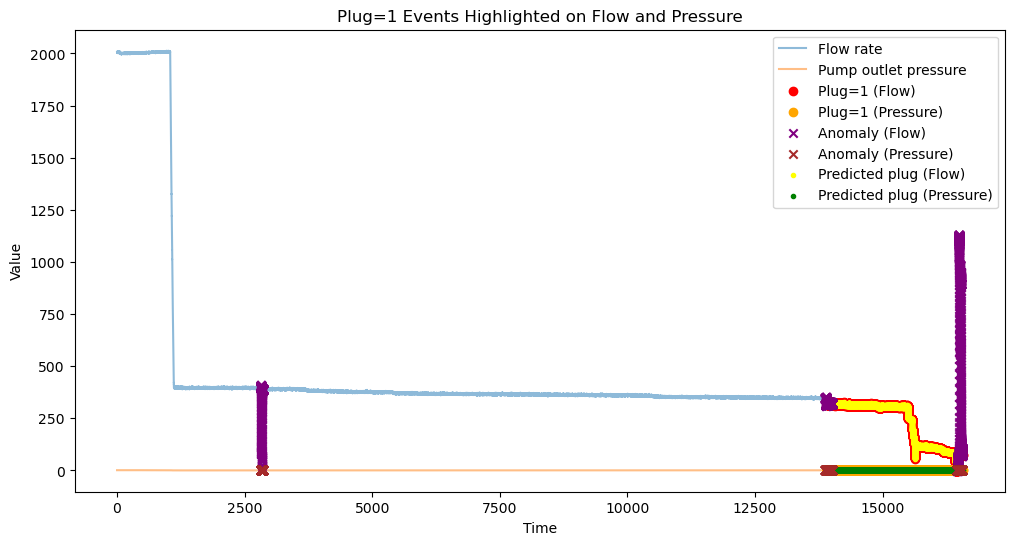

In [ ]:
X_all = pd.concat([X_train, X_val]) #TODO: here we use with all the features, when the model was trained with reduced features
y_all = pd.concat([y_train, y_val])

y_pred = best_model.predict(X_all)

X_all_unscaled_part = dp.descale_features(X_all)

X_all_unscaled = X_all_unscaled_part.copy()
X_all_unscaled['Plug'] = y_all

dv.visualize_predicted_vs_true(X_all_unscaled, y_pred, anomalies=True)


## Test best model on test dataset
Test the best model on the test dataset to check it´s generalization capabilities.

In [ ]:
print(f"Evaluating best model ({best_model.__class__.__name__}) on test set:")
dm.retrain_final_model(X_train, X_val, y_train, y_val, best_model)
y_pred = dm.evaluate_model_on_test(best_model, X_test, y_test)

Evaluating best model (MLPClassifier) on test set:


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[1. 1. 1. ... 1. 1. 1.]
Test set results:
              precision    recall  f1-score   support

         0.0      0.000     0.000     0.000         0
         1.0      1.000     0.997     0.999      1582

    accuracy                          0.997      1582
   macro avg      0.500     0.499     0.499      1582
weighted avg      1.000     0.997     0.999      1582

F1 Score: 0.9987341772151899


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Save best model


In [ ]:
dm.save_model(best_model)

Saved model to ../models/best_pipeline.joblib


### Visualize performance

/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptro

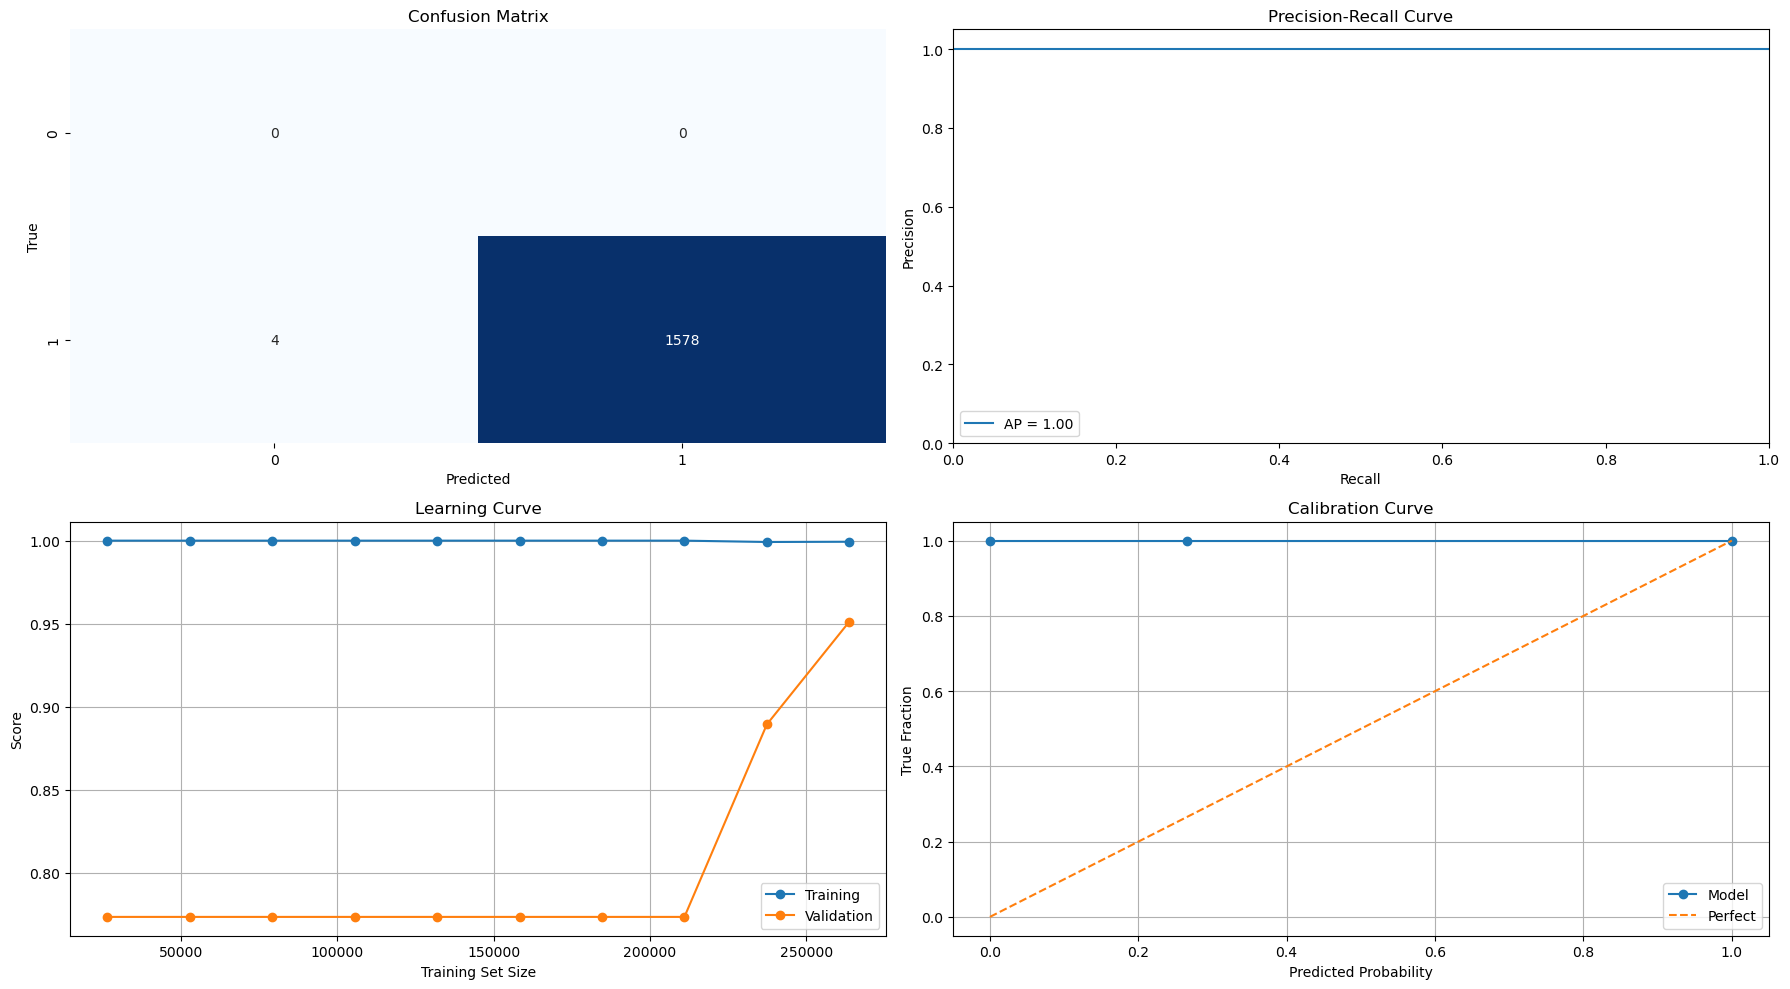

In [ ]:
train_sizes, train_scores, val_scores = dm.get_learning_curve_data(best_model, X_train, y_train)
y_pred_proba = dv.get_y_scores(best_model, X_test)

dv.plot_all(best_model, X_test, y_test, train_sizes, train_scores, val_scores)